# 🏥 HealthSim — Pipeline ML 
### Système Intelligent de Recommandation Hospitalière


---

## 🗺️ Phases du Pipeline

```
┌──────────────────────────────────────────────────────────────────┐
│  Phase 0 │ Imports & Configuration                               │
│  Phase 1 │ Collecte & Exploration des données                    │
│  Phase 2 │ Nettoyage & Transformation                            │
│  Phase 3 │ Feature Engineering                                   │
│  Phase 4 │ Split → KNNImputer (fit train) → RobustScaler (no leakage)           │
│  Phase 5 │ Augmentation : SMOTETomek uniquement                  │
│  Phase 6 │ Entraînement : XGBoost | Random Forest | LightGBM     │
│  Phase 7 │ Évaluation & Sélection automatique du meilleur        │
│  Phase 8 │ Sauvegarde & Fonction de prédiction (production)      │
└──────────────────────────────────────────────────────────────────┘
```

---

###  Installation
```bash
pip install xgboost lightgbm imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib
```

---



---
## 📦 PHASE 0 — Imports & Configuration


In [3]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import joblib

# ── Sklearn ──────────────────────────────────────────────────
from sklearn.model_selection  import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing    import RobustScaler, LabelEncoder
from sklearn.base             import clone
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score
)
from sklearn.metrics import f1_score as sk_f1
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.decomposition import PCA

# ── XGBoost & LightGBM ───────────────────────────────────────
from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('⚠️  LightGBM non installé → pip install lightgbm')

# ── Augmentation ─────────────────────────────────────────────
from imblearn.combine       import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

# ── Style ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

LABEL_MAP  = {0: 'Critique', 1: 'Attention', 2: 'Normal'}
COLOR_MAP  = {0: '#e74c3c',  1: '#f39c12',   2: '#27ae60'}
MODEL_COLORS = {
    'XGBoost':       '#e74c3c',
    'Random Forest': '#3498db',
    'LightGBM':      '#9b59b6',
}

print('✅ Imports OK')
import xgboost, imblearn, sklearn
print(f'   XGBoost {xgboost.__version__} | imbalanced-learn {imblearn.__version__} | sklearn {sklearn.__version__}')
if HAS_LGBM:
    import lightgbm
    print(f'   LightGBM {lightgbm.__version__}')




⚠️  LightGBM non installé → pip install lightgbm
✅ Imports OK
   XGBoost 3.2.0 | imbalanced-learn 0.12.3 | sklearn 1.4.2


---
## 📊 PHASE 1 — Collecte & Exploration des Données


═══════════════════════════════════════════════════════
  INFORMATIONS GÉNÉRALES
═══════════════════════════════════════════════════════
  Dimensions   : 1338 lignes × 17 colonnes
  Années       : ['2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2021-22', '2022-23', '2023-24', '2024-25']
  Mémoire      : 201.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   code_hopital                 1338 non-null   str    
 1   annee_fiscale                1338 non-null   str    
 2   taux_occupation_lits         1338 non-null   float64
 3   taux_mortalite               1338 non-null   float64
 4   taux_infection_nosocomiale   1338 non-null   float64
 5   duree_moyenne_sejour_jours   1338 non-null   float64
 6   temps_attente_median_min     1338 non-null   float64
 7   taux_lits_vacants    

,code_hopital,annee_fiscale,taux_occupation_lits,taux_mortalite,taux_infection_nosocomiale,duree_moyenne_sejour_jours,temps_attente_median_min,taux_lits_vacants,taux_transfert,nombre_lits_disponibles,total_admissions,nombre_medecins,nombre_infirmiers,ratio_medecin_par_lit,ratio_infirmier_par_lit,ratio_infirmier_par_medecin,statut_hopital
0,RE9,2012-13,86.0,4.764,0.0188,5.4,72.0,14.0,14.40,415.000000,37221.0,214.0,NaN,0.516,NaN,NaN,Attention
1,RLN,2012-13,77.3,3.369,0.0495,4.3,109.0,22.7,7.89,887.122222,127379.0,563.0,NaN,0.635,NaN,NaN,Normal
2,RTD,2012-13,84.0,2.417,0.0348,5.0,93.0,16.0,9.45,1608.644444,212396.0,1686.0,NaN,1.048,NaN,NaN,Attention
3,RTF,2012-13,78.4,4.810,0.0468,5.5,107.0,21.6,6.46,1203.522222,113129.0,617.0,NaN,0.513,NaN,NaN,Attention
4,RTR,2012-13,84.5,3.186,0.0325,4.3,103.0,15.5,11.56,1154.322222,150869.0,922.0,NaN,0.799,NaN,NaN,Normal


,taux_occupation_lits,taux_mortalite,taux_infection_nosocomiale,duree_moyenne_sejour_jours,temps_attente_median_min,taux_lits_vacants,taux_transfert,nombre_lits_disponibles,total_admissions,nombre_medecins,nombre_infirmiers,ratio_medecin_par_lit,ratio_infirmier_par_lit,ratio_infirmier_par_medecin
count,1338.000,1338.000,1338.000,1338.000,1338.000,1338.000,1338.000,1338.000,1338.000,1338.000,975.000,1338.000,975.000,975.000
mean,88.900,3.086,0.065,4.195,173.038,11.100,5.637,809.181,115403.810,821.280,1962.042,0.985,2.354,2.349
std,5.224,0.726,0.043,0.697,40.250,5.224,5.263,378.135,53907.617,528.105,1087.974,0.304,0.601,0.516
min,61.300,0.992,0.004,2.566,37.000,0.000,0.010,236.044,23960.000,167.000,390.000,0.496,1.255,1.457
25%,85.700,2.538,0.032,3.700,149.000,7.225,1.660,524.014,74880.000,467.000,1146.000,0.775,1.942,2.019
50%,89.500,3.014,0.053,4.100,172.000,10.500,3.770,721.100,103120.500,637.500,1689.000,0.924,2.253,2.265
75%,92.775,3.591,0.091,4.512,196.000,14.300,7.538,1013.865,146150.000,1014.250,2465.500,1.115,2.662,2.560
max,100.000,5.886,0.440,8.130,345.000,38.700,34.980,2390.967,322880.000,3297.000,8364.000,3.087,6.652,7.106


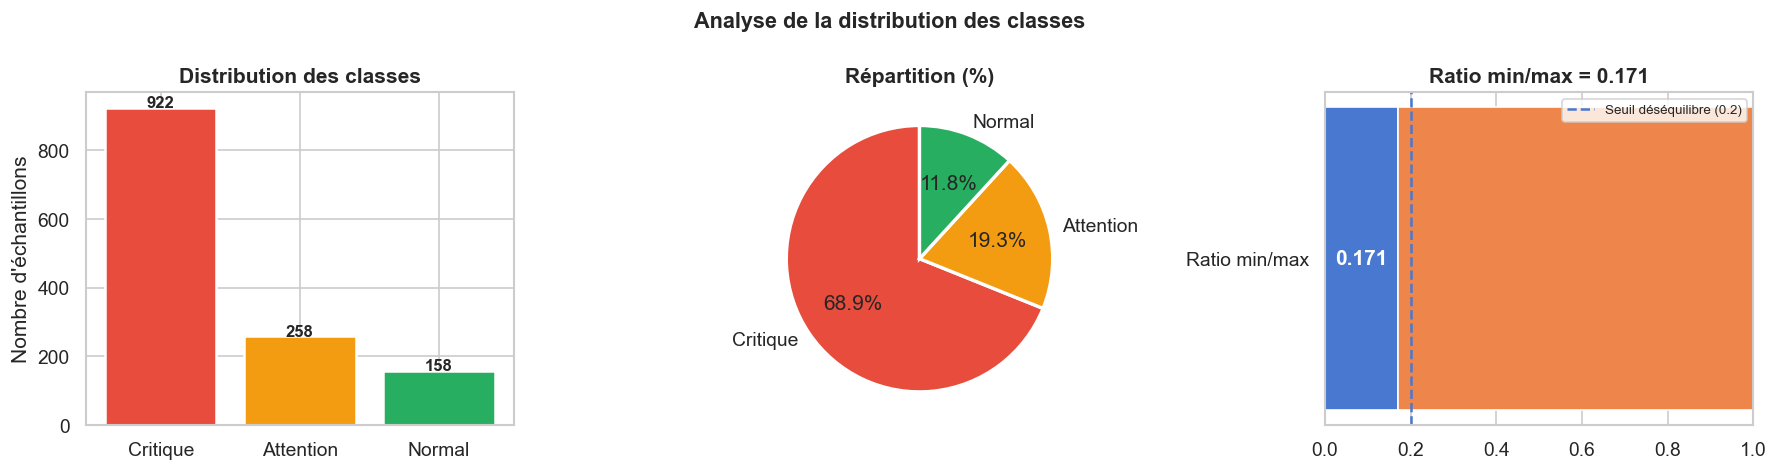

  Critique → 922 (68.9%)
  Attention → 258 (19.3%)
  Normal → 158 (11.8%)

Ratio min/max : 0.171
→ Déséquilibre SÉVÈRE


In [5]:
DATA_PATH = '../data/datasets/nhs_dataset_final.csv'
df = pd.read_csv(DATA_PATH)

print('═'*55)
print('  INFORMATIONS GÉNÉRALES')
print('═'*55)
print(f'  Dimensions   : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'  Années       : {sorted(df["annee_fiscale"].unique())}')
print(f'  Mémoire      : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
df.info()

display(df.head(5))
display(df.describe().round(3))

# ── Encodage cible ───────────────────────────────────────────
le_global = LabelEncoder()
le_global.fit(df['statut_hopital'])
df['statut_encoded'] = le_global.transform(df['statut_hopital'])

# ── Distribution des classes ─────────────────────────────────
class_counts = df['statut_encoded'].value_counts().sort_index()
ratio_min_maj = class_counts.min() / class_counts.max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
bars = ax.bar([LABEL_MAP[i] for i in class_counts.index], class_counts.values,
              color=[COLOR_MAP[i] for i in class_counts.index], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontweight='bold', fontsize=10)
ax.set_title('Distribution des classes', fontweight='bold')
ax.set_ylabel("Nombre d'échantillons")

ax = axes[1]
ax.pie(class_counts.values, labels=[LABEL_MAP[i] for i in class_counts.index],
       colors=[COLOR_MAP[i] for i in class_counts.index],
       autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Répartition (%)', fontweight='bold')

ax = axes[2]
ax.barh(['Ratio min/max'], [ratio_min_maj], height=0.4)
ax.barh(['Ratio min/max'], [1 - ratio_min_maj], left=[ratio_min_maj], height=0.4)
ax.axvline(0.2, linestyle='--', label='Seuil déséquilibre (0.2)')
ax.set_xlim(0, 1)
ax.set_title(f'Ratio min/max = {ratio_min_maj:.3f}', fontweight='bold')
ax.legend(fontsize=8)
ax.text(ratio_min_maj/2, 0, f'{ratio_min_maj:.3f}', ha='center', va='center',
        color='white', fontweight='bold')

plt.suptitle('Analyse de la distribution des classes', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

for cls, cnt in class_counts.items():
    print(f'  {LABEL_MAP[cls]} → {cnt} ({cnt/len(df)*100:.1f}%)')
print(f'\nRatio min/max : {ratio_min_maj:.3f}')
print('→ Déséquilibre SÉVÈRE' if ratio_min_maj < 0.2 else
      '→ Déséquilibre MODÉRÉ' if ratio_min_maj < 0.5 else
      '→ Classes relativement équilibrées')




---
## 🧹 PHASE 2 — Nettoyage & Transformation


═══════════════════════════════════════════════════════
  ÉTAPE 2.1 — Valeurs manquantes (diagnostic)
═══════════════════════════════════════════════════════
⚠️  1089 valeur(s) manquante(s) détectée(s) :
nombre_infirmiers              363
ratio_infirmier_par_lit        363
ratio_infirmier_par_medecin    363
dtype: int64

→ KNNImputer (n_neighbors=5, weights='distance') sera appliqué
  en Phase 4, FIT sur X_train uniquement → zéro data leakage.

═══════════════════════════════════════════════════════
  ÉTAPE 2.2 — Doublons
═══════════════════════════════════════════════════════
Doublons : 0
✅ Aucun doublon

✔ Vérification finale des valeurs manquantes :
1089
═══════════════════════════════════════════════════════
  ÉTAPE 2.3 — Outliers (IQR)
═══════════════════════════════════════════════════════


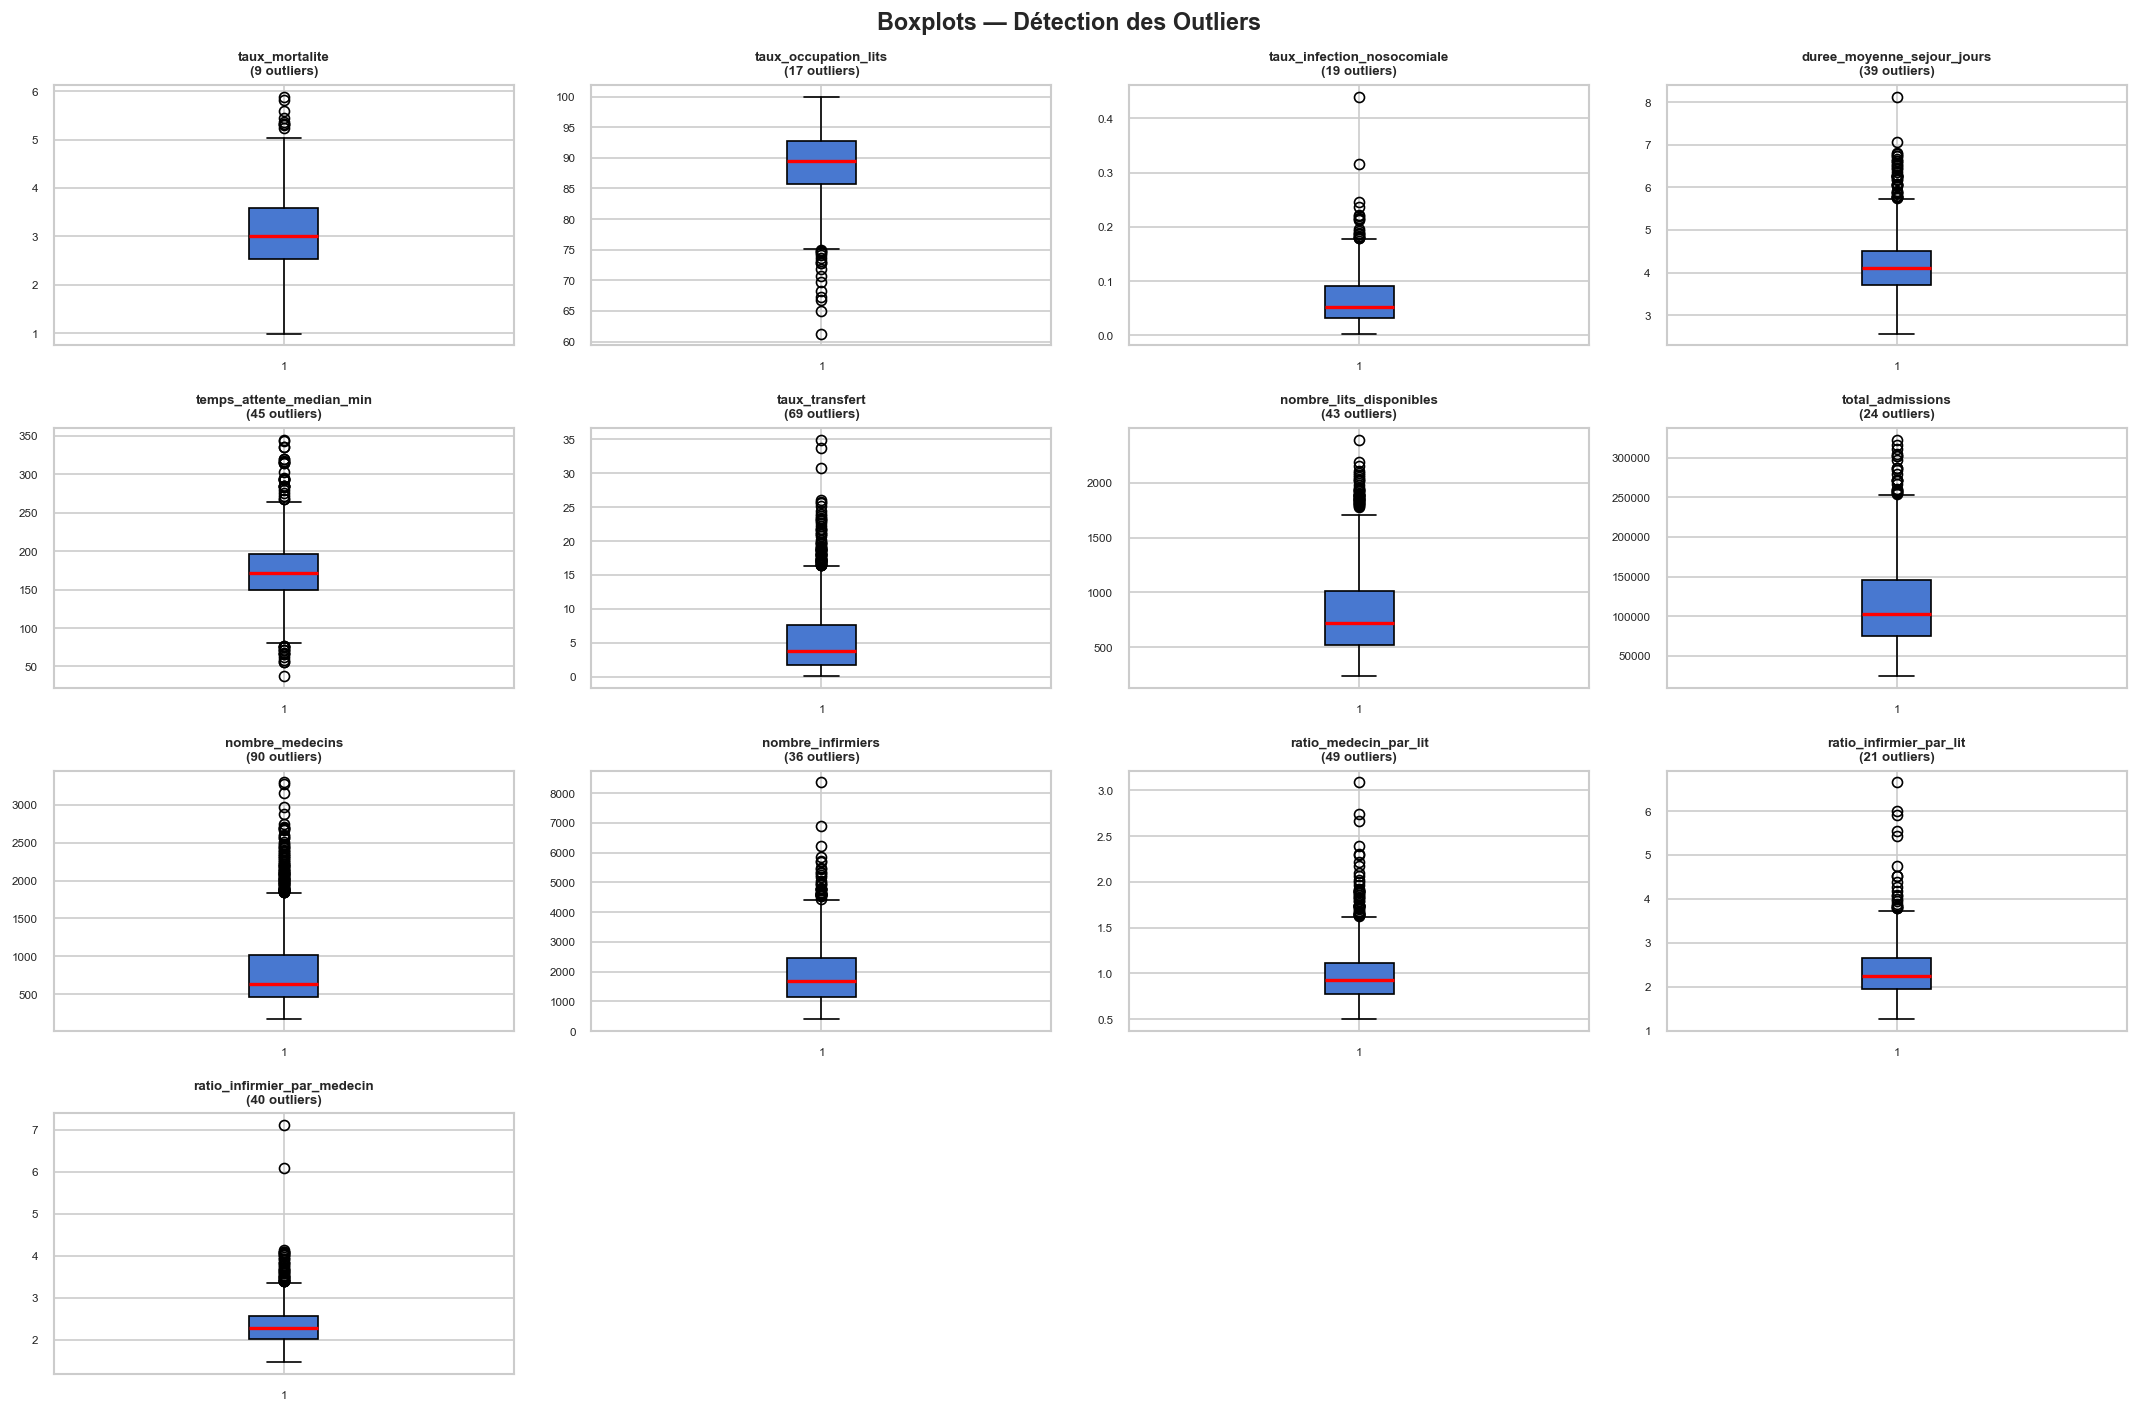

  ÉTAPE 2.4 — Winsorisation IQR
  taux_mortalite                      → 9 valeurs bornées
  taux_occupation_lits                → 17 valeurs bornées
  taux_infection_nosocomiale          → 19 valeurs bornées
  duree_moyenne_sejour_jours          → 39 valeurs bornées
  temps_attente_median_min            → 45 valeurs bornées
  taux_transfert                      → 69 valeurs bornées
  nombre_lits_disponibles             → 43 valeurs bornées
  total_admissions                    → 24 valeurs bornées
  nombre_medecins                     → 90 valeurs bornées
  nombre_infirmiers                   → 36 valeurs bornées
  ratio_medecin_par_lit               → 49 valeurs bornées
  ratio_infirmier_par_lit             → 21 valeurs bornées
  ratio_infirmier_par_medecin         → 40 valeurs bornées

✅ Winsorisation terminée


In [7]:
FEATURES_NUM = [
    'taux_mortalite',
    'taux_occupation_lits',
    'taux_infection_nosocomiale',
    'duree_moyenne_sejour_jours',
    'temps_attente_median_min',
    'taux_transfert',
    'nombre_lits_disponibles',
    'total_admissions',
    'nombre_medecins',
    'nombre_infirmiers',
    'ratio_medecin_par_lit',
    'ratio_infirmier_par_lit',
    'ratio_infirmier_par_medecin'
]
TARGET = 'statut_encoded'


# ════════════════════════════════════════════════════════
# ÉTAPE 2.1 — Valeurs manquantes : diagnostic uniquement
# ⚠️  Le KNNImputer sera fit UNIQUEMENT sur X_train (Phase 4)
#     pour éviter tout data leakage vers le test set.
# ════════════════════════════════════════════════════════

from sklearn.impute import KNNImputer

print('═'*55)
print('  ÉTAPE 2.1 — Valeurs manquantes (diagnostic)')
print('═'*55)

missing = df[FEATURES_NUM].isnull().sum()
n_missing = missing.sum()

if n_missing == 0:
    print('✅ Aucune valeur manquante détectée')
else:
    print(f'⚠️  {n_missing} valeur(s) manquante(s) détectée(s) :')
    print(missing[missing > 0])
    print()
    print('→ KNNImputer (n_neighbors=5, weights=\'distance\') sera appliqué')
    print('  en Phase 4, FIT sur X_train uniquement → zéro data leakage.')

HAS_MISSING = n_missing > 0
print()


# ════════════════════════════════════════════════════════
# ÉTAPE 2.2 — Doublons
# ════════════════════════════════════════════════════════

print('═'*55)
print('  ÉTAPE 2.2 — Doublons')
print('═'*55)

n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup}')

if n_dup > 0:
    df = df.drop_duplicates()
    print(f'→ {n_dup} doublons supprimés')
else:
    print('✅ Aucun doublon')


# ════════════════════════════════════════════════════════
# CHECK FINAL
# ════════════════════════════════════════════════════════

print()
print('✔ Vérification finale des valeurs manquantes :')
print(df[FEATURES_NUM].isnull().sum().sum())

# ── Détection Outliers ───────────────────────────────────────
print('═'*55)
print('  ÉTAPE 2.3 — Outliers (IQR)')
print('═'*55)
X_raw = df[FEATURES_NUM].copy()
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()
outlier_report = []

for i, col in enumerate(FEATURES_NUM):
    Q1, Q3 = X_raw[col].quantile(0.25), X_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((X_raw[col] < lower) | (X_raw[col] > upper)).sum()
    outlier_report.append({'Feature': col, 'Lower': lower, 'Upper': upper, 'Outliers': n_out})
    ax = axes[i]
    ax.boxplot(X_raw[col].dropna(), patch_artist=True, medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col}\n({n_out} outliers)', fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=7)

for j in range(len(FEATURES_NUM), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots — Détection des Outliers', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Winsorisation ────────────────────────────────────────────
print('  ÉTAPE 2.4 — Winsorisation IQR')
X = df[FEATURES_NUM].copy()
y = df[TARGET].values
winsor_bounds = {}

for col in FEATURES_NUM:
    Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_before = ((X[col] < lower) | (X[col] > upper)).sum()
    X[col] = X[col].clip(lower=lower, upper=upper)
    winsor_bounds[col] = (lower, upper)
    if n_before > 0:
        print(f'  {col:<35} → {n_before} valeurs bornées')

print('\n✅ Winsorisation terminée')


---
## ⚙️ PHASE 3 — Feature Engineering


═══════════════════════════════════════════════════════
  Features composites
═══════════════════════════════════════════════════════
  13 KPIs + 4 engineered = 17 features au total


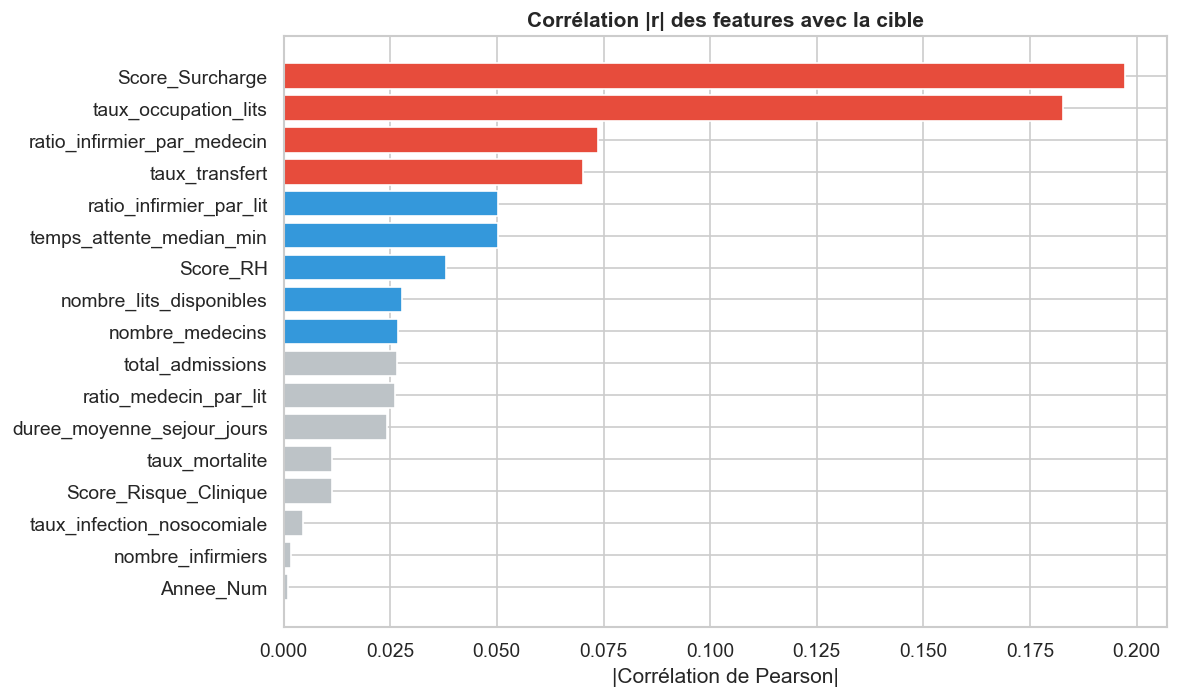

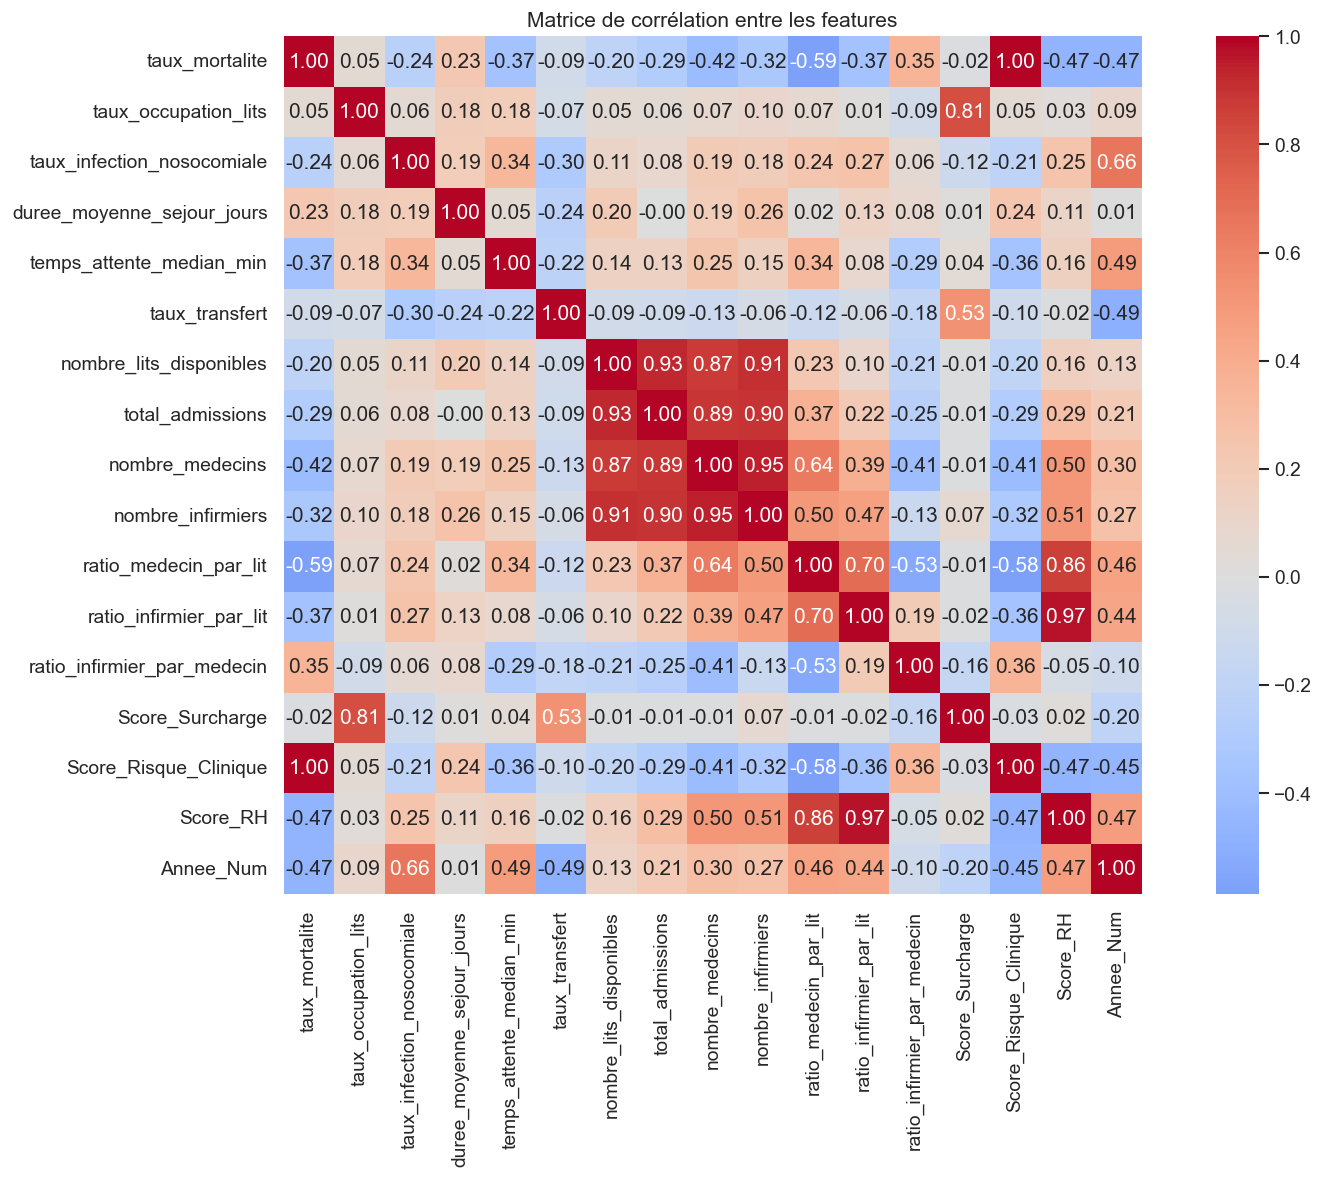

In [9]:
print('═'*55)
print('  Features composites')
print('═'*55)

MAX_ATTENTE = X['temps_attente_median_min'].max()

X['Score_Surcharge'] = (
    X['taux_occupation_lits'] * 0.40
    + X['temps_attente_median_min'] / MAX_ATTENTE * 0.30
    + X['taux_transfert'] * 0.30
)
X['Score_Risque_Clinique'] = (
    X['taux_mortalite'] * 0.60
    + X['taux_infection_nosocomiale'] * 0.40
)
X['Score_RH'] = (
    X['ratio_medecin_par_lit'] * 0.50
    + X['ratio_infirmier_par_lit'] * 0.50
)
X['Annee_Num'] = df['annee_fiscale'].str[:4].astype(int)

FEATURES_ALL = FEATURES_NUM + ['Score_Surcharge', 'Score_Risque_Clinique', 'Score_RH', 'Annee_Num']
print(f'  {len(FEATURES_NUM)} KPIs + 4 engineered = {len(FEATURES_ALL)} features au total')

# ── Corrélation ──────────────────────────────────────────────
corr_target = X[FEATURES_ALL].corrwith(pd.Series(y)).abs().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#e74c3c' if v >= corr_target.quantile(0.8)
              else '#3498db' if v >= corr_target.quantile(0.5)
              else '#bdc3c7' for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors_bar)
ax.set_title('Corrélation |r| des features avec la cible', fontweight='bold')
ax.set_xlabel('|Corrélation de Pearson|')
plt.tight_layout(); plt.show()


# Matrice de corrélation entre les features
corr_matrix = X[FEATURES_ALL].corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Matrice de corrélation entre les features")
plt.tight_layout()
plt.show()


---
## 🔀 PHASE 4 — Prétraitement (split AVANT scaling)


In [11]:
print('═'*55)
print('  Split stratifié 80/20 → KNNImputer → RobustScaler')
print('  Ordre : split → impute (fit train only) → scale (fit train only)')
print('═'*55)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X[FEATURES_ALL], y, test_size=0.20, random_state=42, stratify=y
)

# ── KNN Imputation (fit sur X_train uniquement) ──────────────
# On applique uniquement si des valeurs manquantes existent
imputer = KNNImputer(n_neighbors=5, weights='distance')

# fit_transform sur train, transform uniquement sur test → zéro leakage
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_raw),
    columns=FEATURES_ALL,
    index=X_train_raw.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test_raw),
    columns=FEATURES_ALL,
    index=X_test_raw.index
)

if HAS_MISSING:
    print('  KNNImputer fitté sur X_train → appliqué sur X_test')
else:
    print('  KNNImputer appliqué (aucun NaN détecté — étape neutre)')

# ── RobustScaler (fit sur X_train uniquement) ────────────────
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=FEATURES_ALL)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_imp),      columns=FEATURES_ALL)
X_scaled_full  = scaler.transform(imputer.transform(X[FEATURES_ALL]))  # pour PCA uniquement

print(f'  Train : {X_train_scaled.shape} | Test : {X_test_scaled.shape}')
print('\n  Distribution Train :')
for cls, cnt in sorted(Counter(y_train).items()):
    print(f'    {LABEL_MAP[cls]:15s} → {cnt}')
print('\n  Distribution Test :')
for cls, cnt in sorted(Counter(y_test).items()):
    print(f'    {LABEL_MAP[cls]:15s} → {cnt}')

print()
print('✅ Pipeline no-leakage : split → KNN (fit train) → Scale (fit train)')


═══════════════════════════════════════════════════════
  Split stratifié 80/20 → KNNImputer → RobustScaler
  Ordre : split → impute (fit train only) → scale (fit train only)
═══════════════════════════════════════════════════════
  KNNImputer fitté sur X_train → appliqué sur X_test
  Train : (1070, 17) | Test : (268, 17)

  Distribution Train :
    Critique        → 737
    Attention       → 206
    Normal          → 127

  Distribution Test :
    Critique        → 185
    Attention       → 52
    Normal          → 31

✅ Pipeline no-leakage : split → KNN (fit train) → Scale (fit train)


---
## ⚖️ PHASE 5 — Augmentation : SMOTETomek 


════════════════════════════════════════════════════════════
  STRATÉGIE  — SMOTETomek
  → Interpolation SMOTE + nettoyage des chevauchements Tomek
════════════════════════════════════════════════════════════

  Avant augmentation : 1070 échantillons
  Après augmentation : 2208 échantillons

  Distribution après SMOTETomek :
    Critique        → 734
    Attention       → 737
    Normal          → 737


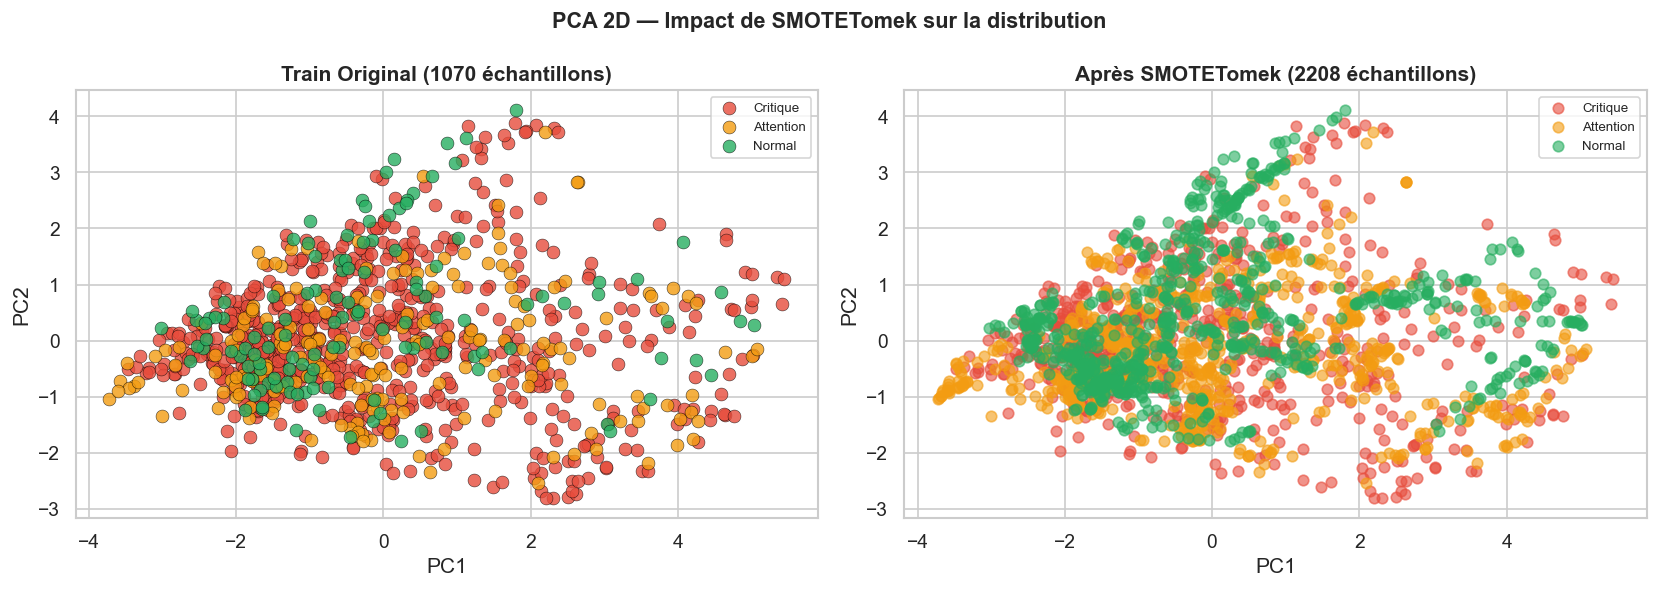

In [13]:
print('═'*60)
print('  STRATÉGIE  — SMOTETomek')
print('  → Interpolation SMOTE + nettoyage des chevauchements Tomek')
print('═'*60)

smotetomek = SMOTETomek(
    smote=SMOTE(k_neighbors=5, random_state=42),
    tomek=TomekLinks(sampling_strategy='majority'),
    random_state=42
)

X_aug, y_aug = smotetomek.fit_resample(X_train_scaled, y_train)

print(f'\n  Avant augmentation : {len(y_train)} échantillons')
print(f'  Après augmentation : {len(y_aug)} échantillons')
print('\n  Distribution après SMOTETomek :')
cnt_aug = Counter(y_aug)
for cls, c in sorted(cnt_aug.items()):
    print(f'    {LABEL_MAP[cls]:15s} → {c}')

# ── PCA 2D : avant / après ───────────────────────────────────
pca = PCA(n_components=2, random_state=42)
pca.fit(X_scaled_full)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
X_tr_2d = pca.transform(X_train_scaled)
for cls in [0, 1, 2]:
    mask = y_train == cls
    ax.scatter(X_tr_2d[mask, 0], X_tr_2d[mask, 1],
               label=LABEL_MAP[cls], alpha=0.8, s=60,
               edgecolors='black', linewidth=0.3, color=COLOR_MAP[cls])
ax.set_title(f'Train Original ({len(y_train)} échantillons)', fontweight='bold')
ax.legend(fontsize=8); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

ax = axes[1]
X_aug_2d = pca.transform(X_aug)
for cls in [0, 1, 2]:
    mask = y_aug == cls
    ax.scatter(X_aug_2d[mask, 0], X_aug_2d[mask, 1],
               label=LABEL_MAP[cls], alpha=0.6, s=40, color=COLOR_MAP[cls])
ax.set_title(f'Après SMOTETomek ({len(y_aug)} échantillons)', fontweight='bold')
ax.legend(fontsize=8); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('PCA 2D — Impact de SMOTETomek sur la distribution', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()




---
## 🚀 PHASE 6 — Entraînement : XGBoost | Random Forest | LightGBM


In [15]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except:
    HAS_LGBM = False


# ─────────────────────────────────────────────
# MODELES OPTIMISÉS
# ─────────────────────────────────────────────
def make_models():
    models = {

        # 🔵 XGBOOST (plus stable, moins overfit)
        'XGBoost': XGBClassifier(
            n_estimators=400,
            max_depth=4,              # ↑ un peu plus expressif
            learning_rate=0.05,       # équilibre vitesse / perf
            subsample=0.8,
            colsample_bytree=0.8,
            gamma=0.2,                # moins agressif que 0.5
            min_child_weight=3,       # meilleur compromis
            reg_alpha=0.5,            # régularisation modérée
            reg_lambda=2.0,
            eval_metric='mlogloss',
            random_state=42,
            verbosity=0
        ),

        # 🌲 RANDOM FOREST (réduction variance)
        'Random Forest': RandomForestClassifier(
            n_estimators=600,
            max_depth=10,             # un peu plus profond mais contrôlé
            class_weight='balanced',
            max_features='sqrt',
            min_samples_leaf=3,       # important pour généralisation
            min_samples_split=8,
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        ),
    }

    # 🟢 LIGHTGBM (très puissant mais contrôlé)
    if HAS_LGBM:
        models['LightGBM'] = LGBMClassifier(
            n_estimators=600,
            learning_rate=0.04,
            max_depth=-1,
            num_leaves=31,            # plus expressif que 20
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=25,
            reg_alpha=0.3,
            reg_lambda=2.0,
            min_split_gain=0.1,
            class_weight='balanced',
            random_state=42,
            verbosity=-1
        )

    # 🌳 EXTRA TREES (robuste baseline)
    else:
        models['ExtraTrees'] = ExtraTreesClassifier(
            n_estimators=700,
            max_depth=None,
            min_samples_leaf=2,
            min_samples_split=6,
            class_weight='balanced',
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        )

    return models


# ─────────────────────────────────────────────
# CROSS VALIDATION
# ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'accuracy': 'accuracy'
}

results = {}

print(f'  {"Modèle":<22} {"F1-Macro":^18} {"F1-Weighted":^14} {"Accuracy":^10}')
print('  ' + '─'*65)

for nom, mod in make_models().items():

    sc = cross_validate(
        mod,
        X_aug,
        y_aug,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results[nom] = {
        'f1_macro': sc['test_f1_macro'].mean(),
        'f1_macro_std': sc['test_f1_macro'].std(),
        'f1_weighted': sc['test_f1_weighted'].mean(),
        'accuracy': sc['test_accuracy'].mean(),
    }

    r = results[nom]

    print(
        f'  {nom:<22} '
        f'{r["f1_macro"]:.4f} ±{r["f1_macro_std"]:.3f}  '
        f'{r["f1_weighted"]:.4f}  '
        f'{r["accuracy"]:.4f}'
    )

print('\n✅ Cross-validation terminée')

  Modèle                      F1-Macro       F1-Weighted    Accuracy 
  ─────────────────────────────────────────────────────────────────
  XGBoost                0.9612 ±0.006  0.9612  0.9615
  Random Forest          0.9558 ±0.004  0.9558  0.9561
  ExtraTrees             0.9555 ±0.007  0.9555  0.9561

✅ Cross-validation terminée


---
## 📈 PHASE 7 — Évaluation & Sélection du Meilleur Modèle


Classement :
       Modèle  F1-Macro CV   ±std  F1-Weighted  Accuracy
      XGBoost       0.9612 0.0060       0.9612    0.9615
Random Forest       0.9558 0.0043       0.9558    0.9561
   ExtraTrees       0.9555 0.0067       0.9555    0.9561

🏆 MEILLEUR MODÈLE : XGBoost
   F1-Macro CV  : 0.9612 ±0.0060


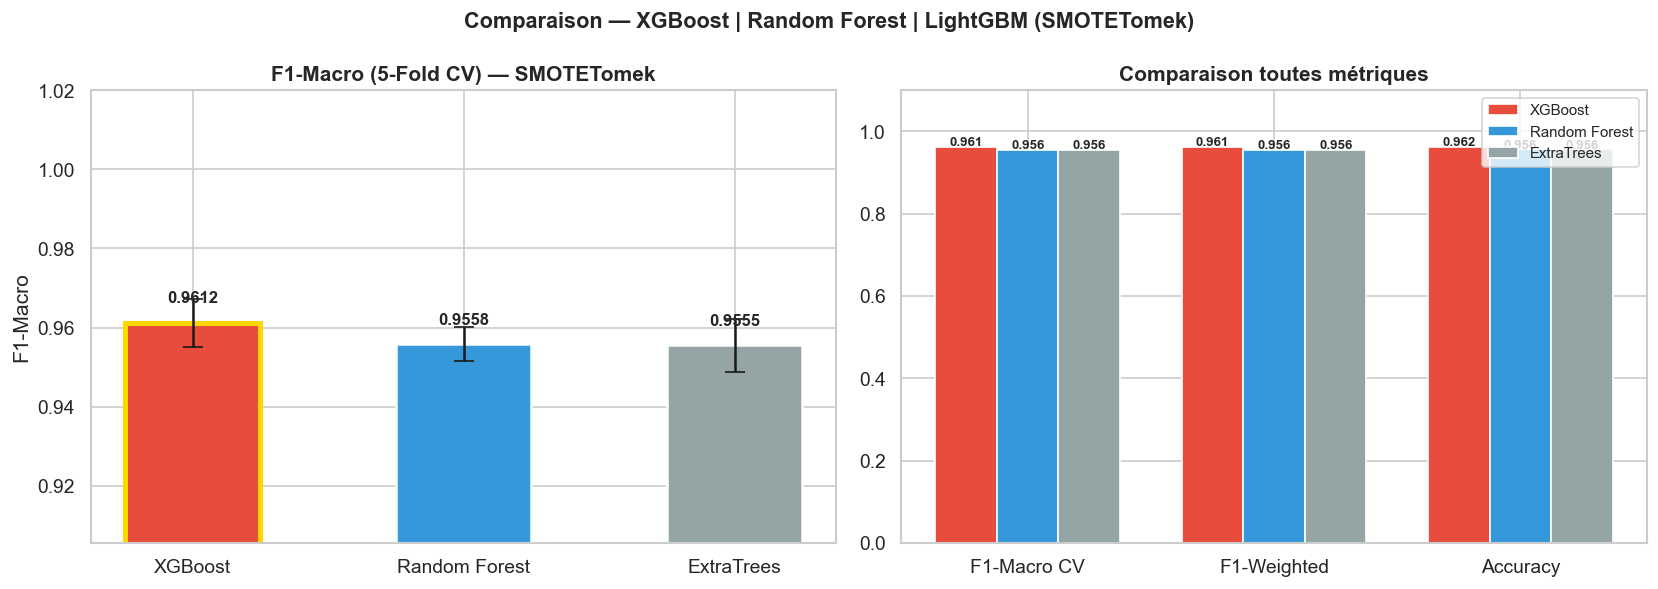


Entraînement final du meilleur modèle : XGBoost

═══════════════════════════════════════════════════════
  RÉSULTATS FINAUX SUR TEST — XGBoost
═══════════════════════════════════════════════════════
               precision    recall  f1-score   support

 Critique (0)       0.98      0.95      0.97       185
Attention (1)       0.92      0.94      0.93        52
   Normal (2)       0.86      1.00      0.93        31

     accuracy                           0.96       268
    macro avg       0.92      0.96      0.94       268
 weighted avg       0.96      0.96      0.96       268

  F1-Macro  : 0.9419
  F1-Weight : 0.9557
  Precision : 0.9230
  Recall    : 0.9646
  ROC-AUC   : 0.9940


In [17]:
df_results = pd.DataFrame([
    {
        'Modèle':      nom,
        'F1-Macro CV': round(r['f1_macro'], 4),
        '±std':        round(r['f1_macro_std'], 4),
        'F1-Weighted': round(r['f1_weighted'], 4),
        'Accuracy':    round(r['accuracy'], 4),
    }
    for nom, r in results.items()
]).sort_values('F1-Macro CV', ascending=False)

print('Classement :')
print(df_results.to_string(index=False))

best_model = df_results.iloc[0]['Modèle']
print(f'\n🏆 MEILLEUR MODÈLE : {best_model}')
print(f'   F1-Macro CV  : {df_results.iloc[0]["F1-Macro CV"]:.4f} ±{df_results.iloc[0]["±std"]:.4f}')

# ── Barplot comparatif ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
noms   = df_results['Modèle'].tolist()
f1s    = df_results['F1-Macro CV'].tolist()
stds   = df_results['±std'].tolist()
cols   = [MODEL_COLORS.get(n, '#95a5a6') for n in noms]
bars   = ax.bar(noms, f1s, yerr=stds, color=cols, capsize=6,
                edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3)
ax.set_ylim(min(f1s) - 0.05, 1.02)
ax.set_title('F1-Macro (5-Fold CV) — SMOTETomek', fontweight='bold')
ax.set_ylabel('F1-Macro')

ax = axes[1]
metrics = ['F1-Macro CV', 'F1-Weighted', 'Accuracy']
x = np.arange(len(metrics))
width = 0.25
for i, (_, row) in enumerate(df_results.iterrows()):
    vals = [row['F1-Macro CV'], row['F1-Weighted'], row['Accuracy']]
    offset = (i - 1) * width
    b = ax.bar(x + offset, vals, width, label=row['Modèle'],
               color=MODEL_COLORS.get(row['Modèle'], '#95a5a6'),
               edgecolor='white', linewidth=1)
    for bar, v in zip(b, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('Comparaison toutes métriques', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Comparaison — XGBoost | Random Forest | LightGBM (SMOTETomek)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Entraînement final + évaluation TEST ─────────────────────
print(f'\nEntraînement final du meilleur modèle : {best_model}')
final_model = make_models()[best_model]
final_model.fit(X_aug, y_aug)

y_pred  = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)

f1_test = f1_score(y_test, y_pred, average='macro')
f1_w    = f1_score(y_test, y_pred, average='weighted')
prec    = precision_score(y_test, y_pred, average='macro')
rec     = recall_score(y_test, y_pred, average='macro')
try:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
except Exception:
    roc_auc = None

print()
print('═'*55)
print(f'  RÉSULTATS FINAUX SUR TEST — {best_model}')
print('═'*55)
print(classification_report(y_test, y_pred,
      target_names=['Critique (0)', 'Attention (1)', 'Normal (2)']))
print(f'  F1-Macro  : {f1_test:.4f}')
print(f'  F1-Weight : {f1_w:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
if roc_auc:
    print(f'  ROC-AUC   : {roc_auc:.4f}')


---
## 💾 PHASE 8 — Sauvegarde & Fonction de Prédiction HealthSim


In [19]:
pipeline_final = {
    'modele':        final_model,
    'nom_modele':    best_model,
    'strategie':     'SMOTETomek',
    'scaler':        scaler,
    'imputer':       imputer,          
    'features_all':  FEATURES_ALL,
    'features_num':  FEATURES_NUM,
    'label_map':     LABEL_MAP,
    'winsor_bounds': winsor_bounds,
    'max_attente':   MAX_ATTENTE,
    'le':            le_global,
    'f1_macro_test': f1_test,
    'df_resultats':  df_results,
}

joblib.dump(pipeline_final, 'healthsim_final_pipeline.pkl')
print(f'✅ Pipeline sauvegardé → healthsim_final_pipeline.pkl')
print(f'   Modèle    : {best_model}')
print(f'   Stratégie : SMOTETomek')
print(f'   F1-Macro  : {f1_test:.4f}')



def predire_statut_service(kpis: dict, seuil_critique: float = 0.35) -> dict:

    d = kpis.copy()

   
    nb_lits       = max(d['nombre_lits_disponibles'], 1)
    nb_medecins   = max(d['nombre_medecins'], 1)
    nb_infirmiers = max(d['nombre_infirmiers'], 1)
    d['ratio_medecin_par_lit']       = nb_medecins   / nb_lits
    d['ratio_infirmier_par_lit']     = nb_infirmiers / nb_lits
    d['ratio_infirmier_par_medecin'] = nb_infirmiers / nb_medecins

    df_in = pd.DataFrame([d])

    # Winsorisation features brutes
    for col, (lo, hi) in winsor_bounds.items():
        if col in df_in.columns:
            df_in[col] = df_in[col].clip(lo, hi)

    # Feature engineering
    df_in['Score_Surcharge'] = (
        df_in['taux_occupation_lits'] * 0.40
        + (df_in['temps_attente_median_min'] / MAX_ATTENTE).clip(0, 1) * 0.30  
        + df_in['taux_transfert'] * 0.30
    )
    df_in['Score_Risque_Clinique'] = (
        df_in['taux_mortalite'] * 0.60
        + df_in['taux_infection_nosocomiale'] * 0.40
    )
    df_in['Score_RH'] = (
        df_in['ratio_medecin_par_lit'] * 0.50
        + df_in['ratio_infirmier_par_lit'] * 0.50
    )
    df_in['Annee_Num'] = int(d.get('annee', 2023))

   
    X_imp = imputer.transform(df_in[FEATURES_ALL].values)
    X_in  = scaler.transform(X_imp)

    proba = final_model.predict_proba(X_in)[0]

    
    if proba[0] >= seuil_critique:
        pred = 0
    elif proba[1] >= 0.20:
        pred = 1
    else:
        pred = 2

    recommandations = {
        0: {'niveau': '🔴 CRITIQUE',  'action': 'Intervention immédiate requise.',
            'details': 'Alerter la direction. Renforcer les ressources humaines et matérielles en urgence.'},
        1: {'niveau': '🟡 ATTENTION', 'action': 'Surveillance renforcée recommandée.',
            'details': 'Réviser la planification. Suivi hebdomadaire des KPIs critiques.'},
        2: {'niveau': '🟢 NORMAL',    'action': 'Continuer le suivi standard.',
            'details': 'Maintenir les bonnes pratiques. Suivi mensuel des KPIs.'},
    }

    return {
        'statut':         pred,
        'label':          LABEL_MAP[pred],
        'probabilites':   {LABEL_MAP[i]: round(float(p), 4) for i, p in enumerate(proba)},
        'confiance':      round(float(proba.max()), 4),
        'recommandation': recommandations[pred],
    }


# ── Tests 4 services du CHU Ibn Badis ────────────────────────
services_chu = {
    'Urgences': {
        'taux_mortalite': 3.2, 'taux_occupation_lits': 0.96,
        'taux_infection_nosocomiale': 0.045, 'duree_moyenne_sejour_jours': 8.5,
        'taux_transfert': 0.23, 'temps_attente_median_min': 120.0,
        'nombre_lits_disponibles': 40, 'total_admissions': 1200,
        'nombre_medecins': 8, 'nombre_infirmiers': 20,
        'annee': 2023,
    },
    'Chirurgie': {
        'taux_mortalite': 1.1, 'taux_occupation_lits': 0.68,
        'taux_infection_nosocomiale': 0.010, 'duree_moyenne_sejour_jours': 3.5,
        'taux_transfert': 0.04, 'temps_attente_median_min': 18.0,
        'nombre_lits_disponibles': 30, 'total_admissions': 600,
        'nombre_medecins': 15, 'nombre_infirmiers': 35,
        'annee': 2023,
    },
    'Médecine Interne': {
        'taux_mortalite': 1.9, 'taux_occupation_lits': 0.82,
        'taux_infection_nosocomiale': 0.018, 'duree_moyenne_sejour_jours': 5.8,
        'taux_transfert': 0.10, 'temps_attente_median_min':
        45.0,
        'nombre_lits_disponibles': 50, 'total_admissions': 900,
        'nombre_medecins': 12, 'nombre_infirmiers': 30,
        'annee': 2023,
    },
    'Réanimation': {
        'taux_mortalite': 2.1, 'taux_occupation_lits': 0.90,
        'taux_infection_nosocomiale': 0.030, 'duree_moyenne_sejour_jours': 7.2,
        'taux_transfert': 0.16, 'temps_attente_median_min': 70.0,
        'nombre_lits_disponibles': 20, 'total_admissions': 400,
        'nombre_medecins': 10, 'nombre_infirmiers': 25,
        'annee': 2023,
    },
}

print('═'*60)
print('  SYSTÈME DE RECOMMANDATION — CHU IBN BADIS CONSTANTINE')
print(f'  Modèle : {best_model} | Stratégie : SMOTETomek')
print('═'*60)
for service, kpis in services_chu.items():
    r = predire_statut_service(kpis)
    print(f'\n  🏥 Service {service}')
    print(f'     Statut    : {r["recommandation"]["niveau"]}')
    print(f'     Action    : {r["recommandation"]["action"]}')
    print(f'     Confiance : {r["confiance"]*100:.1f}%  |  {r["probabilites"]}')

✅ Pipeline sauvegardé → healthsim_final_pipeline.pkl
   Modèle    : XGBoost
   Stratégie : SMOTETomek
   F1-Macro  : 0.9419
════════════════════════════════════════════════════════════
  SYSTÈME DE RECOMMANDATION — CHU IBN BADIS CONSTANTINE
  Modèle : XGBoost | Stratégie : SMOTETomek
════════════════════════════════════════════════════════════

  🏥 Service Urgences
     Statut    : 🔴 CRITIQUE
     Action    : Intervention immédiate requise.
     Confiance : 59.5%  |  {'Critique': 0.3998, 'Attention': 0.0056, 'Normal': 0.5946}

  🏥 Service Chirurgie
     Statut    : 🟢 NORMAL
     Action    : Continuer le suivi standard.
     Confiance : 98.9%  |  {'Critique': 0.0108, 'Attention': 0.0001, 'Normal': 0.9891}

  🏥 Service Médecine Interne
     Statut    : 🔴 CRITIQUE
     Action    : Intervention immédiate requise.
     Confiance : 58.0%  |  {'Critique': 0.4159, 'Attention': 0.0046, 'Normal': 0.5795}

  🏥 Service Réanimation
     Statut    : 🔴 CRITIQUE
     Action    : Intervention immédiate

In [20]:

# ── Tests 4 services du CHU Ibn Badis ────────────────────────
services_chu = {
    'Urgences': {
        'taux_mortalite': 3.2, 'taux_occupation_lits': 0.96,
        'taux_infection_nosocomiale': 0.045, 'duree_moyenne_sejour_jours': 8.5,
        'taux_transfert': 0.23, 'temps_attente_median_min': 120.0,
        'nombre_lits_disponibles': 40, 'total_admissions': 1200,
        'nombre_medecins': 8, 'nombre_infirmiers': 20,
        'ratio_medecin_par_lit': 0.07, 'ratio_infirmier_par_lit': 0.18,
        'ratio_infirmier_par_medecin': 1.9, 'annee': 2023,
    },
    'Chirurgie': {
        'taux_mortalite': 1.1, 'taux_occupation_lits': 0.68,
        'taux_infection_nosocomiale': 0.010, 'duree_moyenne_sejour_jours': 3.5,
        'taux_transfert': 0.04, 'temps_attente_median_min': 18.0,
        'nombre_lits_disponibles': 30, 'total_admissions': 600,
        'nombre_medecins': 15, 'nombre_infirmiers': 35,
        'ratio_medecin_par_lit': 0.22, 'ratio_infirmier_par_lit': 0.50,
        'ratio_infirmier_par_medecin': 3.2, 'annee': 2023,
    },
    'Médecine Interne': {
        'taux_mortalite': 1.9, 'taux_occupation_lits': 0.82,
        'taux_infection_nosocomiale': 0.018, 'duree_moyenne_sejour_jours': 5.8,
        'taux_transfert': 0.10, 'temps_attente_median_min': 45.0,
        'nombre_lits_disponibles': 50, 'total_admissions': 900,
        'nombre_medecins': 12, 'nombre_infirmiers': 30,
        'ratio_medecin_par_lit': 0.15, 'ratio_infirmier_par_lit': 0.35,
        'ratio_infirmier_par_medecin': 2.8, 'annee': 2023,
    },
    'Réanimation': {
        'taux_mortalite': 2.1, 'taux_occupation_lits': 0.90,
        'taux_infection_nosocomiale': 0.030, 'duree_moyenne_sejour_jours': 7.2,
        'taux_transfert': 0.16, 'temps_attente_median_min': 70.0,
        'nombre_lits_disponibles': 20, 'total_admissions': 400,
        'nombre_medecins': 10, 'nombre_infirmiers': 25,
        'ratio_medecin_par_lit': 0.10, 'ratio_infirmier_par_lit': 0.28,
        'ratio_infirmier_par_medecin': 2.3, 'annee': 2023,
    },
}

print('═'*60)
print('  SYSTÈME DE RECOMMANDATION — CHU IBN BADIS CONSTANTINE')
print(f'  Modèle : {best_model} | Stratégie : SMOTETomek')
print('═'*60)
for service, kpis in services_chu.items():
    r = predire_statut_service(kpis)
    print(f'\n  🏥 Service {service}')
    print(f'     Statut    : {r["recommandation"]["niveau"]}')
    print(f'     Action    : {r["recommandation"]["action"]}')
    print(f'     Confiance : {r["confiance"]*100:.1f}%  |  {r["probabilites"]}')


════════════════════════════════════════════════════════════
  SYSTÈME DE RECOMMANDATION — CHU IBN BADIS CONSTANTINE
  Modèle : XGBoost | Stratégie : SMOTETomek
════════════════════════════════════════════════════════════

  🏥 Service Urgences
     Statut    : 🔴 CRITIQUE
     Action    : Intervention immédiate requise.
     Confiance : 59.5%  |  {'Critique': 0.3998, 'Attention': 0.0056, 'Normal': 0.5946}

  🏥 Service Chirurgie
     Statut    : 🟢 NORMAL
     Action    : Continuer le suivi standard.
     Confiance : 98.9%  |  {'Critique': 0.0108, 'Attention': 0.0001, 'Normal': 0.9891}

  🏥 Service Médecine Interne
     Statut    : 🔴 CRITIQUE
     Action    : Intervention immédiate requise.
     Confiance : 58.0%  |  {'Critique': 0.4159, 'Attention': 0.0046, 'Normal': 0.5795}

  🏥 Service Réanimation
     Statut    : 🔴 CRITIQUE
     Action    : Intervention immédiate requise.
     Confiance : 60.4%  |  {'Critique': 0.391, 'Attention': 0.0048, 'Normal': 0.6042}
